# Safe Final Colab Run

Use this notebook when you want to avoid losing work to Colab resets. It restores saved metadata, extracted `.ply` files, and split CSVs from Google Drive when available. If the Cap3D ZIP is missing from the Colab runtime, it downloads it temporarily, extracts only the selected subset, then saves only the smaller extracted subset/results to Drive.

Important: the Cap3D ZIP is about 26 GB, larger than a free 15 GB Google Drive. This notebook does not save the ZIP to Drive.


In [1]:
REPO_URL = "https://github.com/SalmaneSossey/graphcnn-federated-3d.git"
REPO_DIR = "/content/graphcnn-federated-3d"
BRANCH = "main"

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/graphcnn-federated-3d"
DRIVE_METADATA_CSV = f"{DRIVE_PROJECT_DIR}/labeled_dataset.csv"
DRIVE_PROCESSED_DIR = f"{DRIVE_PROJECT_DIR}/processed/pointclouds"
DRIVE_SPLITS_DIR = f"{DRIVE_PROJECT_DIR}/splits"
DRIVE_RUNS_DIR = f"{DRIVE_PROJECT_DIR}/runs"

# Safety controls
AUTO_DOWNLOAD_ZIP_IF_MISSING = True
PREPARE_REAL_SUBSET = True
USE_REAL_POINT_CLOUDS = True
SAVE_TO_DRIVE_AFTER_EACH_STAGE = True
FORCE_REEXTRACT_SUBSET = False
POINTCLOUD_ROOT = "data/processed/pointclouds"

# Practical final run that should fit better under Colab limits.
FAST_DEV_RUN = False
SEED = 42
NUM_POINTS = 1024
SUBSET_CLASSES = 10
SAMPLES_PER_CLASS = 200
BATCH_SIZE = 32

CENTRALIZED_EPOCHS = 15
HFL_ROUNDS = 3
HFL_LOCAL_EPOCHS = 1
VFL_EPOCHS = 8
DISTILL_EPOCHS = 6
NUM_CLIENTS = 5

print("Repo:", REPO_URL)
print("Drive project:", DRIVE_PROJECT_DIR)
print("Auto-download ZIP if missing:", AUTO_DOWNLOAD_ZIP_IF_MISSING)
print("Prepare real subset:", PREPARE_REAL_SUBSET)
print("Use real point clouds:", USE_REAL_POINT_CLOUDS)
print("Samples per class:", SAMPLES_PER_CLASS)
print("Centralized epochs:", CENTRALIZED_EPOCHS)
print("HFL rounds:", HFL_ROUNDS)
print("VFL epochs:", VFL_EPOCHS)
print("Distillation epochs:", DISTILL_EPOCHS)
print("ZIP policy: runtime-only; not saved to Drive")


Repo: https://github.com/SalmaneSossey/graphcnn-federated-3d.git
Drive project: /content/drive/MyDrive/graphcnn-federated-3d
Auto-download ZIP if missing: True
Prepare real subset: True
Use real point clouds: True
Samples per class: 200
Centralized epochs: 15
HFL rounds: 3
VFL epochs: 8
Distillation epochs: 6
ZIP policy: runtime-only; not saved to Drive


## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Clone or Update Repo

In [3]:
from pathlib import Path
import os
import shutil
import subprocess


def run(command, check=True):
    print("$", " ".join(str(part) for part in command))
    return subprocess.run(command, check=check)

repo_path = Path(REPO_DIR)
if repo_path.exists():
    os.chdir(REPO_DIR)
    run(["git", "fetch", "origin"])
    run(["git", "checkout", BRANCH])
    run(["git", "pull", "--ff-only", "origin", BRANCH])
else:
    run(["git", "clone", "--branch", BRANCH, REPO_URL, REPO_DIR])
    os.chdir(REPO_DIR)

print("Working directory:", os.getcwd())

$ git clone --branch main https://github.com/SalmaneSossey/graphcnn-federated-3d.git /content/graphcnn-federated-3d
Working directory: /content/graphcnn-federated-3d


## 3. Install Dependencies

In [4]:
!python -m pip install --upgrade pip
!python -m pip install -r requirements-colab.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


## 4. Imports, Device, and Backup Helpers

In [5]:
import copy
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

from src.data.dataset import ShapeNetPointCloudDataset
from src.distillation.losses import distillation_loss
from src.federated.fedavg import aggregate_state_dicts
from src.federated.vfl import VFLEntityEncoder, VFLServerClassifier, split_xyz_rgb
from src.models.common import count_parameters
from src.models.pointgcn import PointGCN
from src.models.rscnn import RSCNN
from src.models.student import StudentPointCloudMLP
from src.training.metrics import accuracy, mean_per_class_accuracy
from src.utils.seed import seed_everything

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for folder in ["data/metadata", "data/raw/PointCloud_zips_ShapeNet", "data/processed/pointclouds", "data/splits", "outputs", "checkpoints", "reports/figures"]:
    Path(folder).mkdir(parents=True, exist_ok=True)
for folder in [Path(DRIVE_PROJECT_DIR), Path(DRIVE_PROCESSED_DIR), Path(DRIVE_SPLITS_DIR), Path(DRIVE_RUNS_DIR)]:
    folder.mkdir(parents=True, exist_ok=True)


def copy_file_if_exists(src, dst, overwrite=False):
    src = Path(src)
    dst = Path(dst)
    if not src.exists():
        print("Missing:", src)
        return False
    if dst.exists() and not overwrite:
        print("Already exists:", dst)
        return True
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    print("Copied", src, "->", dst)
    return True


def copytree_if_exists(src, dst, overwrite=False):
    src = Path(src)
    dst = Path(dst)
    if not src.exists():
        print("Missing:", src)
        return False
    if dst.exists() and overwrite:
        shutil.rmtree(dst)
    if dst.exists() and not overwrite:
        print("Already exists:", dst)
        return True
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(src, dst)
    print("Copied", src, "->", dst)
    return True


def backup_stage(stage_name):
    if not SAVE_TO_DRIVE_AFTER_EACH_STAGE:
        return
    stage_dir = Path(DRIVE_RUNS_DIR) / stage_name
    stage_dir.mkdir(parents=True, exist_ok=True)
    for folder in ["outputs", "checkpoints", "reports/figures", "data/splits"]:
        copytree_if_exists(folder, stage_dir / folder, overwrite=True)
    print("Backed up stage to:", stage_dir)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
!nvidia-smi || true

Torch: 2.11.0+cu128
CUDA available: True
Device: Tesla T4
Thu Jun  4 15:47:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |              

## 5. Restore Smaller Files From Drive

This restores metadata, extracted `.ply` files, and split CSVs if they were saved previously. It intentionally does not restore the 26 GB ZIP from Drive because free Drive storage is too small.


In [6]:
copy_file_if_exists(DRIVE_METADATA_CSV, "data/metadata/labeled_dataset.csv", overwrite=True)
copytree_if_exists(DRIVE_PROCESSED_DIR, "data/processed/pointclouds", overwrite=False)
copytree_if_exists(DRIVE_SPLITS_DIR, "data/splits", overwrite=False)

print("Runtime ZIP, if still present from this Colab session:")
!ls -lh data/raw/PointCloud_zips_ShapeNet/ || true
print("Runtime splits:")
!ls -lh data/splits/ || true
print("Runtime pointcloud count:")
!find data/processed/pointclouds -name '*.ply' | wc -l || true


Missing: /content/drive/MyDrive/graphcnn-federated-3d/labeled_dataset.csv
Already exists: data/processed/pointclouds
Already exists: data/splits
Runtime ZIP, if still present from this Colab session:
total 0
Runtime splits:
total 0
Runtime pointcloud count:
0


## 6. Download ZIP Only If Needed

The ZIP is about 26 GB, so it is kept only in the temporary Colab runtime. After extraction, the notebook saves the smaller selected subset to Drive.


In [7]:
runtime_zip = Path("data/raw/PointCloud_zips_ShapeNet/compressed_pcs_00.zip")
if runtime_zip.exists():
    print("ZIP already available in runtime:", runtime_zip)
elif AUTO_DOWNLOAD_ZIP_IF_MISSING:
    !python scripts/download_cap3d.py --data-dir data/raw
else:
    print("ZIP missing and AUTO_DOWNLOAD_ZIP_IF_MISSING=False")

if not runtime_zip.exists():
    raise FileNotFoundError("Cap3D ZIP is missing. Enable AUTO_DOWNLOAD_ZIP_IF_MISSING to download it temporarily.")

print("ZIP is available temporarily in Colab runtime:", runtime_zip)
print("Not saving ZIP to Drive because free Drive storage is too small for a 26 GB archive.")


PointCloud_zips_ShapeNet/compressed_pcs_(…): 100% 27.3G/27.3G [04:09<00:00, 110MB/s] 
PointCloud_zips_ShapeNet/compressed_file(…): 100% 2.30M/2.30M [00:01<00:00, 1.72MB/s]
Cap3D_automated_ShapeNet.csv: 100% 19.5M/19.5M [00:01<00:00, 12.8MB/s]
pointcloud_zip: data/raw/PointCloud_zips_ShapeNet/compressed_pcs_00.zip
files_info: data/raw/PointCloud_zips_ShapeNet/compressed_files_info.pkl
captions_csv: data/raw/Cap3D_automated_ShapeNet.csv
ZIP is available temporarily in Colab runtime: data/raw/PointCloud_zips_ShapeNet/compressed_pcs_00.zip
Not saving ZIP to Drive because free Drive storage is too small for a 26 GB archive.


## 7. Prepare or Restore Real PLY Subset, Then Save It Immediately

In [8]:
pointcloud_count = len(list(Path("data/processed/pointclouds").glob("*.ply")))
real_split_paths = [Path(f"data/splits/{name}.csv") for name in ["train", "val", "test"]]
splits_ready = all(path.exists() for path in real_split_paths)

if FORCE_REEXTRACT_SUBSET or pointcloud_count == 0 or not splits_ready:
    if not PREPARE_REAL_SUBSET:
        raise RuntimeError("Subset is missing but PREPARE_REAL_SUBSET=False.")
    !python scripts/prepare_subset.py --subset-classes {SUBSET_CLASSES} --samples-per-class {SAMPLES_PER_CLASS}
else:
    print(f"Using restored subset: {pointcloud_count} .ply files and existing split CSVs.")

copytree_if_exists("data/processed/pointclouds", DRIVE_PROCESSED_DIR, overwrite=True)
copytree_if_exists("data/splits", DRIVE_SPLITS_DIR, overwrite=True)

print("Prepared splits:")
!ls -lh data/splits/
print("Prepared pointcloud count:")
!find data/processed/pointclouds -name '*.ply' | wc -l

Traceback (most recent call last):
  File "/content/graphcnn-federated-3d/scripts/prepare_subset.py", line 166, in <module>
    main()
  File "/content/graphcnn-federated-3d/scripts/prepare_subset.py", line 125, in main
    raise FileNotFoundError(f"Missing metadata CSV: {args.metadata_csv}")
FileNotFoundError: Missing metadata CSV: data/metadata/labeled_dataset.csv
Copied data/processed/pointclouds -> /content/drive/MyDrive/graphcnn-federated-3d/processed/pointclouds
Copied data/splits -> /content/drive/MyDrive/graphcnn-federated-3d/splits
Prepared splits:
total 0
Prepared pointcloud count:
0


## 8. Metadata Inspection and Balanced Subset

In [10]:
repo_metadata = Path("data/metadata/labeled_dataset.csv")

if repo_metadata.exists():
    metadata = pd.read_csv(repo_metadata)
    print("Metadata rows:", len(metadata))
    print("Columns:", list(metadata.columns))
    display(metadata.head())
else:
    fallback_labels = [f"class_{i}" for i in range(SUBSET_CLASSES)]
    metadata = pd.DataFrame(
        {
            "id": [f"synthetic_{label}_{idx}" for label in fallback_labels for idx in range(SAMPLES_PER_CLASS)],
            "description": ["synthetic fallback point cloud"] * (len(fallback_labels) * SAMPLES_PER_CLASS),
            "label": [label for label in fallback_labels for _ in range(SAMPLES_PER_CLASS)],
        }
    )
    print("Using synthetic fallback metadata.")
    display(metadata.head())

label_candidates = [c for c in metadata.columns if "label" in c.lower() or "class" in c.lower() or "category" in c.lower()]
label_col = "label" if "label" in metadata.columns else (label_candidates[0] if label_candidates else None)
if label_col is None:
    raise ValueError("Could not infer a label column. Add a `label` column to labeled_dataset.csv.")

label_counts = metadata[label_col].astype(str).value_counts()
chosen_labels = label_counts.head(SUBSET_CLASSES).index.tolist()
subset_df = (
    metadata[metadata[label_col].astype(str).isin(chosen_labels)]
    .assign(label_name=lambda frame: frame[label_col].astype(str))
    .groupby("label_name", group_keys=False)
    .head(SAMPLES_PER_CLASS)
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)
label_to_idx = {label: idx for idx, label in enumerate(sorted(subset_df["label_name"].unique()))}
subset_df["label_idx"] = subset_df["label_name"].map(label_to_idx).astype(int)
num_classes = len(label_to_idx)

print("Chosen labels:", chosen_labels)
print("Subset rows:", len(subset_df))
print("Num classes:", num_classes)
display(subset_df["label_name"].value_counts().rename_axis("label").reset_index(name="count"))
subset_df.to_csv("data/splits/selected_subset.csv", index=False)

Using synthetic fallback metadata.


,id,description,label
0,synthetic_class_0_0,synthetic fallback point cloud,class_0
1,synthetic_class_0_1,synthetic fallback point cloud,class_0
2,synthetic_class_0_2,synthetic fallback point cloud,class_0
3,synthetic_class_0_3,synthetic fallback point cloud,class_0
4,synthetic_class_0_4,synthetic fallback point cloud,class_0


Chosen labels: ['class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9']
Subset rows: 2000
Num classes: 10


,label,count
0,class_9,200
1,class_1,200
2,class_6,200
3,class_4,200
4,class_8,200
5,class_0,200
6,class_5,200
7,class_2,200
8,class_3,200
9,class_7,200


## 9. Train/Validation/Test Split Selection

In [11]:
def stratified_split(frame, label_column="label_idx", train_frac=0.70, val_frac=0.15, seed=42):
    rng = np.random.default_rng(seed)
    train_parts, val_parts, test_parts = [], [], []

    for _, group in frame.groupby(label_column):
        indices = group.index.to_numpy()
        rng.shuffle(indices)

        n = len(indices)
        n_train = max(1, int(round(n * train_frac)))
        n_val = max(1, int(round(n * val_frac))) if n - n_train > 1 else 0

        train_parts.append(frame.loc[indices[:n_train]])
        val_parts.append(frame.loc[indices[n_train:n_train + n_val]])
        test_parts.append(frame.loc[indices[n_train + n_val:]])

    return {
        "train": pd.concat(train_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True),
        "val": pd.concat(val_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True),
        "test": pd.concat(test_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True),
    }


real_split_paths = {name: Path(f"data/splits/{name}.csv") for name in ["train", "val", "test"]}
real_split_ready = (
    USE_REAL_POINT_CLOUDS
    and all(path.exists() for path in real_split_paths.values())
    and all("file_path" in pd.read_csv(path, nrows=1).columns for path in real_split_paths.values())
)

if real_split_ready:
    print("Real split CSVs already exist from prepare_subset.py. Keeping them.")
    splits = {name: pd.read_csv(path) for name, path in real_split_paths.items()}
else:
    print("Creating synthetic/metadata split CSVs.")
    splits = stratified_split(subset_df, seed=SEED)

    for name, split_df in splits.items():
        split_df.to_csv(f"data/splits/{name}.csv", index=False)
        print(name, split_df.shape)

Creating synthetic/metadata split CSVs.
train (1400, 5)
val (300, 5)
test (300, 5)


## 10. Dataset Selection

In [12]:
class SyntheticPointCloudDataset(Dataset):
    def __init__(self, frame, num_points=256, input_channels=6, seed=42):
        self.frame = frame.reset_index(drop=True)
        self.num_points = num_points
        self.input_channels = input_channels
        self.seed = seed
        self.class_ids = sorted(self.frame["label_idx"].unique())
        rng = np.random.default_rng(seed)
        self.centers = {
            class_id: rng.normal(loc=0.0, scale=1.5, size=(1, 6)).astype(np.float32)
            for class_id in self.class_ids
        }

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        label = int(row["label_idx"])
        stable_id = str(row.get("id", index))
        item_seed = (abs(hash((stable_id, label, self.seed))) % (2**32 - 1))
        rng = np.random.default_rng(item_seed)
        center = self.centers[label]
        points = center + rng.normal(0.0, 0.35, size=(self.num_points, 6)).astype(np.float32)
        points[:, :3] -= points[:, :3].mean(axis=0, keepdims=True)
        scale = np.linalg.norm(points[:, :3], axis=1).max()
        if scale > 0:
            points[:, :3] /= scale
        points[:, 3:] = np.clip(points[:, 3:], 0.0, 1.0)
        if self.input_channels == 3:
            points = points[:, :3]
        return torch.from_numpy(points).float(), torch.tensor(label, dtype=torch.long)


def real_split_csvs_are_ready(split_paths, pointcloud_root):
    if not all(path.exists() for path in split_paths.values()):
        return False, "train/val/test split CSVs are missing"
    try:
        split_frames = {name: pd.read_csv(path) for name, path in split_paths.items()}
    except Exception as exc:
        return False, f"could not read split CSVs: {exc}"
    required_columns = {"file_path", "label_idx"}
    for name, frame in split_frames.items():
        missing = required_columns.difference(frame.columns)
        if missing:
            return False, f"{name}.csv is missing columns: {sorted(missing)}"
        if frame.empty:
            return False, f"{name}.csv is empty"
    combined = pd.concat(split_frames.values(), ignore_index=True)
    sample_paths = combined["file_path"].head(25).astype(str)
    existing = []
    for relative_path in sample_paths:
        candidate = Path(relative_path)
        if not candidate.is_absolute():
            candidate = Path(pointcloud_root) / candidate
        existing.append(candidate.exists())
    if not any(existing):
        return False, f"no referenced .ply files found under {pointcloud_root}"
    return True, split_frames

split_paths = {name: Path(f"data/splits/{name}.csv") for name in ["train", "val", "test"]}
real_ready, real_info = real_split_csvs_are_ready(split_paths, POINTCLOUD_ROOT)

if USE_REAL_POINT_CLOUDS and real_ready:
    print("Using real extracted PLY datasets.")
    splits = real_info
    num_classes = int(pd.concat(splits.values())["label_idx"].nunique())
    train_dataset = ShapeNetPointCloudDataset(split_paths["train"], POINTCLOUD_ROOT, NUM_POINTS, label_column="label_idx")
    val_dataset = ShapeNetPointCloudDataset(split_paths["val"], POINTCLOUD_ROOT, NUM_POINTS, label_column="label_idx")
    test_dataset = ShapeNetPointCloudDataset(split_paths["test"], POINTCLOUD_ROOT, NUM_POINTS, label_column="label_idx")
else:
    if USE_REAL_POINT_CLOUDS:
        print(f"Requested real point clouds, but they are not ready: {real_info}")
        print("Falling back to synthetic proxy. Run prepare_subset successfully, then rerun with USE_REAL_POINT_CLOUDS=True.")
    else:
        print("Using synthetic point-cloud proxy.")
    train_dataset = SyntheticPointCloudDataset(splits["train"], num_points=NUM_POINTS, seed=SEED)
    val_dataset = SyntheticPointCloudDataset(splits["val"], num_points=NUM_POINTS, seed=SEED)
    test_dataset = SyntheticPointCloudDataset(splits["test"], num_points=NUM_POINTS, seed=SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

points, targets = next(iter(train_loader))
print("Batch points:", points.shape)
print("Batch labels:", targets.shape)
print("Num classes:", num_classes)


Requested real point clouds, but they are not ready: train.csv is missing columns: ['file_path']
Falling back to synthetic proxy. Run prepare_subset successfully, then rerun with USE_REAL_POINT_CLOUDS=True.
Batch points: torch.Size([32, 1024, 6])
Batch labels: torch.Size([32])
Num classes: 10


## 11. Shared Training Helpers

In [13]:
criterion = nn.CrossEntropyLoss()
experiment_rows = []


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    logits_all, targets_all = [], []
    with torch.no_grad():
        for points, targets in loader:
            points = points.to(device)
            targets = targets.to(device)
            logits = model(points)
            loss = criterion(logits, targets)
            total_loss += loss.item() * targets.size(0)
            logits_all.append(logits.cpu())
            targets_all.append(targets.cpu())
    logits = torch.cat(logits_all)
    targets = torch.cat(targets_all)
    return {
        "loss": total_loss / max(len(targets), 1),
        "accuracy": accuracy(logits, targets),
        "mpca": mean_per_class_accuracy(logits, targets, num_classes=num_classes),
    }


def train_model(model, train_loader, val_loader, epochs, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_examples = 0
        for points, targets in train_loader:
            points = points.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(points)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_examples += targets.size(0)
        val_metrics = evaluate(model, val_loader)
        history.append({"epoch": epoch, "train_loss": total_loss / max(total_examples, 1), **val_metrics})
        print(f"epoch={epoch:02d} train_loss={history[-1]['train_loss']:.4f} val_acc={val_metrics['accuracy']:.4f}")
    return model, pd.DataFrame(history)


def record_result(config_name, model_name, metrics, params=None, notes=""):
    row = {
        "configuration": config_name,
        "model": model_name,
        "test_loss": metrics["loss"],
        "test_accuracy": metrics["accuracy"],
        "test_mpca": metrics["mpca"],
        "parameters": params,
        "notes": notes,
    }
    experiment_rows.append(row)
    return row

## 12. C1 Centralized Baselines

In [14]:
centralized_models = {
    "PointGCN": PointGCN(num_classes=num_classes, input_channels=6, hidden_dim=64),
    "RS-CNN": RSCNN(num_classes=num_classes, input_channels=6, hidden_dim=64),
}
trained_centralized = {}

for model_name, model in centralized_models.items():
    print("=== Centralized", model_name, "===")
    print("Parameters:", count_parameters(model))
    trained_model, history = train_model(model, train_loader, val_loader, epochs=CENTRALIZED_EPOCHS)
    test_metrics = evaluate(trained_model, test_loader)
    display(pd.DataFrame([test_metrics]))
    history.to_csv(f"outputs/history_centralized_{model_name.lower().replace('-', '').replace(' ', '_')}.csv", index=False)
    torch.save(trained_model.state_dict(), f"checkpoints/{model_name.lower().replace('-', '').replace(' ', '_')}_centralized.pt")
    record_result("C1 Centralized", model_name, test_metrics, count_parameters(trained_model))
    trained_centralized[model_name] = trained_model

teacher_model = trained_centralized["PointGCN"]

=== Centralized PointGCN ===
Parameters: 9418
epoch=01 train_loss=2.2348 val_acc=0.7700
epoch=02 train_loss=1.7365 val_acc=0.8467
epoch=03 train_loss=0.8387 val_acc=0.9833
epoch=04 train_loss=0.2895 val_acc=1.0000
epoch=05 train_loss=0.1121 val_acc=0.9933
epoch=06 train_loss=0.0494 val_acc=1.0000
epoch=07 train_loss=0.0284 val_acc=1.0000
epoch=08 train_loss=0.0187 val_acc=1.0000
epoch=09 train_loss=0.0136 val_acc=1.0000
epoch=10 train_loss=0.0104 val_acc=1.0000
epoch=11 train_loss=0.0086 val_acc=1.0000
epoch=12 train_loss=0.0064 val_acc=1.0000
epoch=13 train_loss=0.0057 val_acc=1.0000
epoch=14 train_loss=0.0045 val_acc=1.0000
epoch=15 train_loss=0.0039 val_acc=1.0000


,loss,accuracy,mpca
0,0.004171,1.0,1.0


=== Centralized RS-CNN ===
Parameters: 9418
epoch=01 train_loss=2.1733 val_acc=0.7533
epoch=02 train_loss=1.4525 val_acc=0.6800
epoch=03 train_loss=0.6747 val_acc=0.8967
epoch=04 train_loss=0.2904 val_acc=1.0000
epoch=05 train_loss=0.1154 val_acc=0.9967
epoch=06 train_loss=0.0529 val_acc=0.9967
epoch=07 train_loss=0.0297 val_acc=1.0000
epoch=08 train_loss=0.0194 val_acc=1.0000
epoch=09 train_loss=0.0148 val_acc=1.0000
epoch=10 train_loss=0.0109 val_acc=1.0000
epoch=11 train_loss=0.0085 val_acc=1.0000
epoch=12 train_loss=0.0069 val_acc=1.0000
epoch=13 train_loss=0.0061 val_acc=1.0000
epoch=14 train_loss=0.0048 val_acc=1.0000
epoch=15 train_loss=0.0039 val_acc=1.0000


,loss,accuracy,mpca
0,0.004232,1.0,1.0


In [15]:
backup_stage("after_centralized")

Copied outputs -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_centralized/outputs
Copied checkpoints -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_centralized/checkpoints
Copied reports/figures -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_centralized/reports/figures
Copied data/splits -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_centralized/data/splits
Backed up stage to: /content/drive/MyDrive/graphcnn-federated-3d/runs/after_centralized


## 13. C2/C3 Manual Horizontal Federated Learning

In [16]:
def make_iid_client_loaders(dataset, num_clients, batch_size, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)
    client_indices = np.array_split(indices, num_clients)
    return [DataLoader(Subset(dataset, idx.tolist()), batch_size=batch_size, shuffle=True) for idx in client_indices]


def make_non_iid_client_loaders(frame, num_clients, batch_size, seed=42):
    sorted_frame = frame.sort_values(["label_idx"]).reset_index(drop=True)
    shards = np.array_split(np.arange(len(sorted_frame)), num_clients)
    loaders = []
    for shard in shards:
        client_frame = sorted_frame.iloc[shard].reset_index(drop=True)
        client_dataset = SyntheticPointCloudDataset(client_frame, num_points=NUM_POINTS, seed=seed)
        loaders.append(DataLoader(client_dataset, batch_size=batch_size, shuffle=True))
    return loaders


def train_local_client(global_model, client_loader, local_epochs=1, lr=1e-3):
    local_model = copy.deepcopy(global_model).to(device)
    optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)
    for _ in range(local_epochs):
        local_model.train()
        for points, targets in client_loader:
            points = points.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = local_model(points)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
    state = {key: value.detach().cpu() for key, value in local_model.state_dict().items()}
    return state, len(client_loader.dataset)


def run_hfl_experiment(name, client_loaders):
    global_model = PointGCN(num_classes=num_classes, input_channels=6, hidden_dim=64).to(device)
    round_rows = []
    for round_idx in range(1, HFL_ROUNDS + 1):
        client_states, client_sizes = [], []
        for client_id, client_loader in enumerate(client_loaders):
            state, size = train_local_client(global_model, client_loader, local_epochs=HFL_LOCAL_EPOCHS)
            client_states.append(state)
            client_sizes.append(size)
        aggregated = aggregate_state_dicts(client_states, client_sizes)
        global_model.load_state_dict(aggregated)
        val_metrics = evaluate(global_model, val_loader)
        round_row = {"round": round_idx, "client_sizes": client_sizes, **val_metrics}
        round_rows.append(round_row)
        print(f"{name} round={round_idx:02d} val_acc={val_metrics['accuracy']:.4f} sizes={client_sizes}")
    test_metrics = evaluate(global_model, test_loader)
    pd.DataFrame(round_rows).to_csv(f"outputs/history_{name.lower().replace(' ', '_')}.csv", index=False)
    record_result(name, "PointGCN FedAvg", test_metrics, count_parameters(global_model), notes=f"{NUM_CLIENTS} clients")
    return global_model, pd.DataFrame(round_rows)

iid_loaders = make_iid_client_loaders(train_dataset, NUM_CLIENTS, BATCH_SIZE, seed=SEED)
non_iid_loaders = make_non_iid_client_loaders(splits["train"], NUM_CLIENTS, BATCH_SIZE, seed=SEED)

hfl_iid_model, hfl_iid_history = run_hfl_experiment("C2 HFL IID", iid_loaders)
hfl_non_iid_model, hfl_non_iid_history = run_hfl_experiment("C3 HFL non-IID", non_iid_loaders)

C2 HFL IID round=01 val_acc=0.1000 sizes=[280, 280, 280, 280, 280]
C2 HFL IID round=02 val_acc=0.3000 sizes=[280, 280, 280, 280, 280]
C2 HFL IID round=03 val_acc=0.4100 sizes=[280, 280, 280, 280, 280]
C3 HFL non-IID round=01 val_acc=0.0433 sizes=[280, 280, 280, 280, 280]
C3 HFL non-IID round=02 val_acc=0.1000 sizes=[280, 280, 280, 280, 280]
C3 HFL non-IID round=03 val_acc=0.1000 sizes=[280, 280, 280, 280, 280]


In [17]:
backup_stage("after_hfl")

Copied outputs -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_hfl/outputs
Copied checkpoints -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_hfl/checkpoints
Copied reports/figures -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_hfl/reports/figures
Copied data/splits -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_hfl/data/splits
Backed up stage to: /content/drive/MyDrive/graphcnn-federated-3d/runs/after_hfl


## 14. Vertical Federated Learning

In [18]:
class VFLSystem(nn.Module):
    def __init__(self, embedding_dim=64, num_classes=10):
        super().__init__()
        self.entity_a = VFLEntityEncoder(input_channels=3, embedding_dim=embedding_dim)
        self.entity_b = VFLEntityEncoder(input_channels=3, embedding_dim=embedding_dim)
        self.server = VFLServerClassifier(embedding_dim=embedding_dim, num_classes=num_classes)

    def forward(self, points):
        xyz, rgb = split_xyz_rgb(points)
        embedding_a = self.entity_a(xyz)
        embedding_b = self.entity_b(rgb)
        return self.server(embedding_a, embedding_b)

vfl_model = VFLSystem(embedding_dim=64, num_classes=num_classes).to(device)
print("VFL parameters:", count_parameters(vfl_model))
vfl_model, vfl_history = train_model(vfl_model, train_loader, val_loader, epochs=VFL_EPOCHS)
vfl_metrics = evaluate(vfl_model, test_loader)
record_result("VFL", "XYZ/RGB Embedding Split", vfl_metrics, count_parameters(vfl_model), notes="Entity A=XYZ, Entity B=RGB")
display(pd.DataFrame([vfl_metrics]))
vfl_history.to_csv("outputs/history_vfl.csv", index=False)

VFL parameters: 17738
epoch=01 train_loss=2.2088 val_acc=0.5400
epoch=02 train_loss=1.5624 val_acc=0.6133
epoch=03 train_loss=0.8980 val_acc=0.6867
epoch=04 train_loss=0.6105 val_acc=0.8100
epoch=05 train_loss=0.3969 val_acc=0.8900
epoch=06 train_loss=0.2614 val_acc=0.9000
epoch=07 train_loss=0.1943 val_acc=0.9933
epoch=08 train_loss=0.1655 val_acc=0.8967


,loss,accuracy,mpca
0,0.16201,0.896667,0.896667


In [19]:
backup_stage("after_vfl")

Copied outputs -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_vfl/outputs
Copied checkpoints -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_vfl/checkpoints
Copied reports/figures -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_vfl/reports/figures
Copied data/splits -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_vfl/data/splits
Backed up stage to: /content/drive/MyDrive/graphcnn-federated-3d/runs/after_vfl


## 15. Knowledge Distillation

In [20]:
def train_student_with_distillation(teacher, alpha, temperature):
    teacher = teacher.to(device).eval()
    student = StudentPointCloudMLP(num_classes=num_classes, input_channels=6, hidden_dim=16).to(device)
    teacher_params = count_parameters(teacher)
    student_params = count_parameters(student)
    print(f"Teacher params={teacher_params:,} Student params={student_params:,} Ratio={teacher_params / max(student_params, 1):.2f}x")
    optimizer = torch.optim.Adam(student.parameters(), lr=1e-3)
    history = []
    for epoch in range(1, DISTILL_EPOCHS + 1):
        student.train()
        total_loss = 0.0
        total_examples = 0
        for points, targets in train_loader:
            points = points.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            student_logits = student(points)
            with torch.no_grad():
                teacher_logits = teacher(points)
            loss = distillation_loss(student_logits, teacher_logits, targets, alpha=alpha, temperature=temperature)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_examples += targets.size(0)
        val_metrics = evaluate(student, val_loader)
        history.append({"epoch": epoch, "train_loss": total_loss / max(total_examples, 1), "alpha": alpha, "temperature": temperature, **val_metrics})
        print(f"alpha={alpha} tau={temperature} epoch={epoch:02d} val_acc={val_metrics['accuracy']:.4f}")
    return student, pd.DataFrame(history)

kd_runs = []
for alpha, temperature in [(0.3, 2.0), (0.5, 4.0), (0.7, 4.0)]:
    print("=== Distillation", alpha, temperature, "===")
    student, kd_history = train_student_with_distillation(teacher_model, alpha=alpha, temperature=temperature)
    metrics = evaluate(student, test_loader)
    kd_history.to_csv(f"outputs/history_kd_alpha_{alpha}_tau_{temperature}.csv", index=False)
    record_result("C4 Distillation", f"Student alpha={alpha} tau={temperature}", metrics, count_parameters(student), notes="Teacher=centralized PointGCN")
    kd_runs.append((alpha, temperature, student, metrics))

=== Distillation 0.3 2.0 ===
Teacher params=9,418 Student params=826 Ratio=11.40x
alpha=0.3 tau=2.0 epoch=01 val_acc=0.1833
alpha=0.3 tau=2.0 epoch=02 val_acc=0.2500
alpha=0.3 tau=2.0 epoch=03 val_acc=0.4467
alpha=0.3 tau=2.0 epoch=04 val_acc=0.4933
alpha=0.3 tau=2.0 epoch=05 val_acc=0.5267
alpha=0.3 tau=2.0 epoch=06 val_acc=0.7433
=== Distillation 0.5 4.0 ===
Teacher params=9,418 Student params=826 Ratio=11.40x
alpha=0.5 tau=4.0 epoch=01 val_acc=0.1933
alpha=0.5 tau=4.0 epoch=02 val_acc=0.2000
alpha=0.5 tau=4.0 epoch=03 val_acc=0.3033
alpha=0.5 tau=4.0 epoch=04 val_acc=0.3533
alpha=0.5 tau=4.0 epoch=05 val_acc=0.5533
alpha=0.5 tau=4.0 epoch=06 val_acc=0.5733
=== Distillation 0.7 4.0 ===
Teacher params=9,418 Student params=826 Ratio=11.40x
alpha=0.7 tau=4.0 epoch=01 val_acc=0.2000
alpha=0.7 tau=4.0 epoch=02 val_acc=0.3900
alpha=0.7 tau=4.0 epoch=03 val_acc=0.2000
alpha=0.7 tau=4.0 epoch=04 val_acc=0.2000
alpha=0.7 tau=4.0 epoch=05 val_acc=0.3800
alpha=0.7 tau=4.0 epoch=06 val_acc=0.726

In [21]:
backup_stage("after_distillation")

Copied outputs -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_distillation/outputs
Copied checkpoints -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_distillation/checkpoints
Copied reports/figures -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_distillation/reports/figures
Copied data/splits -> /content/drive/MyDrive/graphcnn-federated-3d/runs/after_distillation/data/splits
Backed up stage to: /content/drive/MyDrive/graphcnn-federated-3d/runs/after_distillation


## 16. Comparison and Final Backup

,configuration,model,test_loss,test_accuracy,test_mpca,parameters,notes
0,C1 Centralized,PointGCN,0.004171,1.000000,1.000000,9418,
1,C1 Centralized,RS-CNN,0.004232,1.000000,1.000000,9418,
2,VFL,XYZ/RGB Embedding Split,0.162010,0.896667,0.896667,17738,"Entity A=XYZ, Entity B=RGB"
3,C4 Distillation,Student alpha=0.3 tau=2.0,0.786816,0.766667,0.766667,826,Teacher=centralized PointGCN
4,C4 Distillation,Student alpha=0.7 tau=4.0,0.861235,0.723333,0.723333,826,Teacher=centralized PointGCN
5,C4 Distillation,Student alpha=0.5 tau=4.0,0.975115,0.573333,0.573333,826,Teacher=centralized PointGCN
6,C2 HFL IID,PointGCN FedAvg,2.173603,0.403333,0.403333,9418,5 clients
7,C3 HFL non-IID,PointGCN FedAvg,2.290388,0.100000,0.100000,9418,5 clients


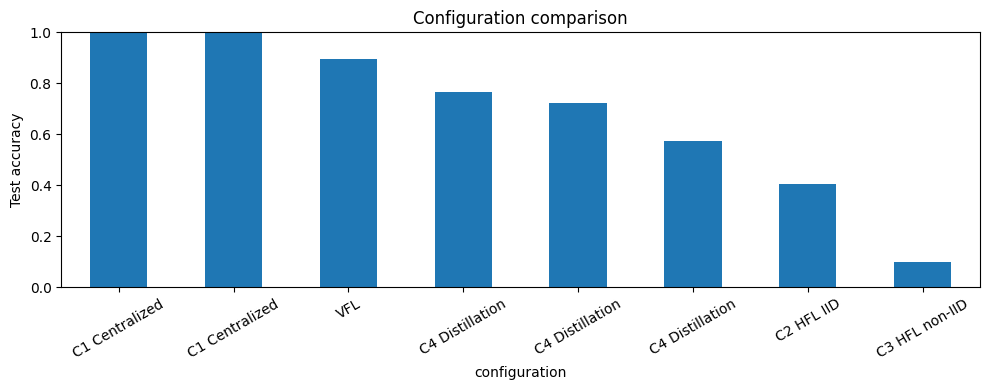

Best configuration: C1 Centralized | PointGCN | accuracy= 1.0
Saved comparison to outputs/comparison_metrics.csv


In [22]:
results_df = pd.DataFrame(experiment_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
results_df.to_csv("outputs/comparison_metrics.csv", index=False)
display(results_df)

try:
    import matplotlib.pyplot as plt

    ax = results_df.plot.bar(x="configuration", y="test_accuracy", legend=False, figsize=(10, 4), rot=30)
    ax.set_ylabel("Test accuracy")
    ax.set_ylim(0, 1)
    ax.set_title("Configuration comparison")
    plt.tight_layout()
    plt.savefig("reports/figures/configuration_comparison.png", dpi=160)
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

best = results_df.iloc[0]
print("Best configuration:", best["configuration"], "|", best["model"], "| accuracy=", round(float(best["test_accuracy"]), 4))
print("Saved comparison to outputs/comparison_metrics.csv")

In [23]:
final_dir = Path(DRIVE_RUNS_DIR) / ("final_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
final_dir.mkdir(parents=True, exist_ok=True)
for folder in ["outputs", "checkpoints", "reports/figures", "data/splits"]:
    copytree_if_exists(folder, final_dir / folder, overwrite=True)
print("Final backup:", final_dir)
!git status --short

Copied outputs -> /content/drive/MyDrive/graphcnn-federated-3d/runs/final_20260604_155550/outputs
Copied checkpoints -> /content/drive/MyDrive/graphcnn-federated-3d/runs/final_20260604_155550/checkpoints
Copied reports/figures -> /content/drive/MyDrive/graphcnn-federated-3d/runs/final_20260604_155550/reports/figures
Copied data/splits -> /content/drive/MyDrive/graphcnn-federated-3d/runs/final_20260604_155550/data/splits
Final backup: /content/drive/MyDrive/graphcnn-federated-3d/runs/final_20260604_155550
?? reports/figures/configuration_comparison.png
